DATASET:
Training set: 494 patients
Testing set:  124 patients
Myopic in training: 65
Myopic in testing:  16

Decision Tree trained successfully!
DECISION TREE RESULTS:
Accuracy:  0.7903
ROC AUC:   0.7060

Classification Report:
              precision    recall  f1-score   support

  Not Myopic       0.95      0.81      0.87       108
      Myopic       0.34      0.69      0.46        16

    accuracy                           0.79       124
   macro avg       0.64      0.75      0.66       124
weighted avg       0.87      0.79      0.82       124



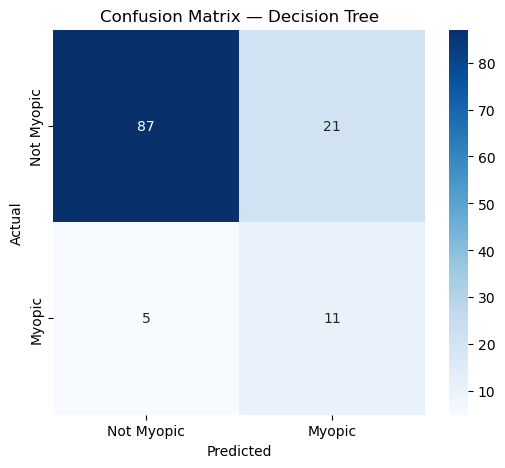

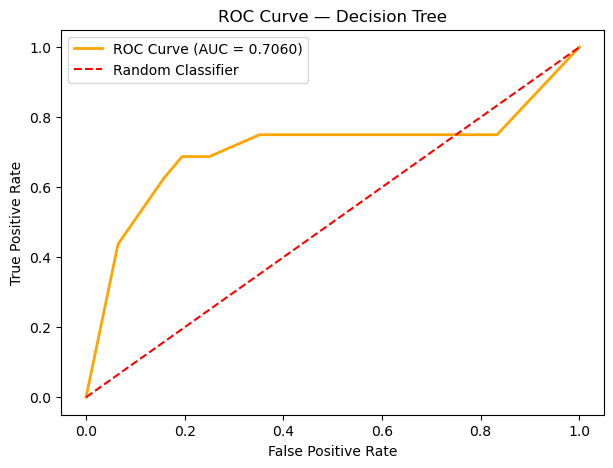

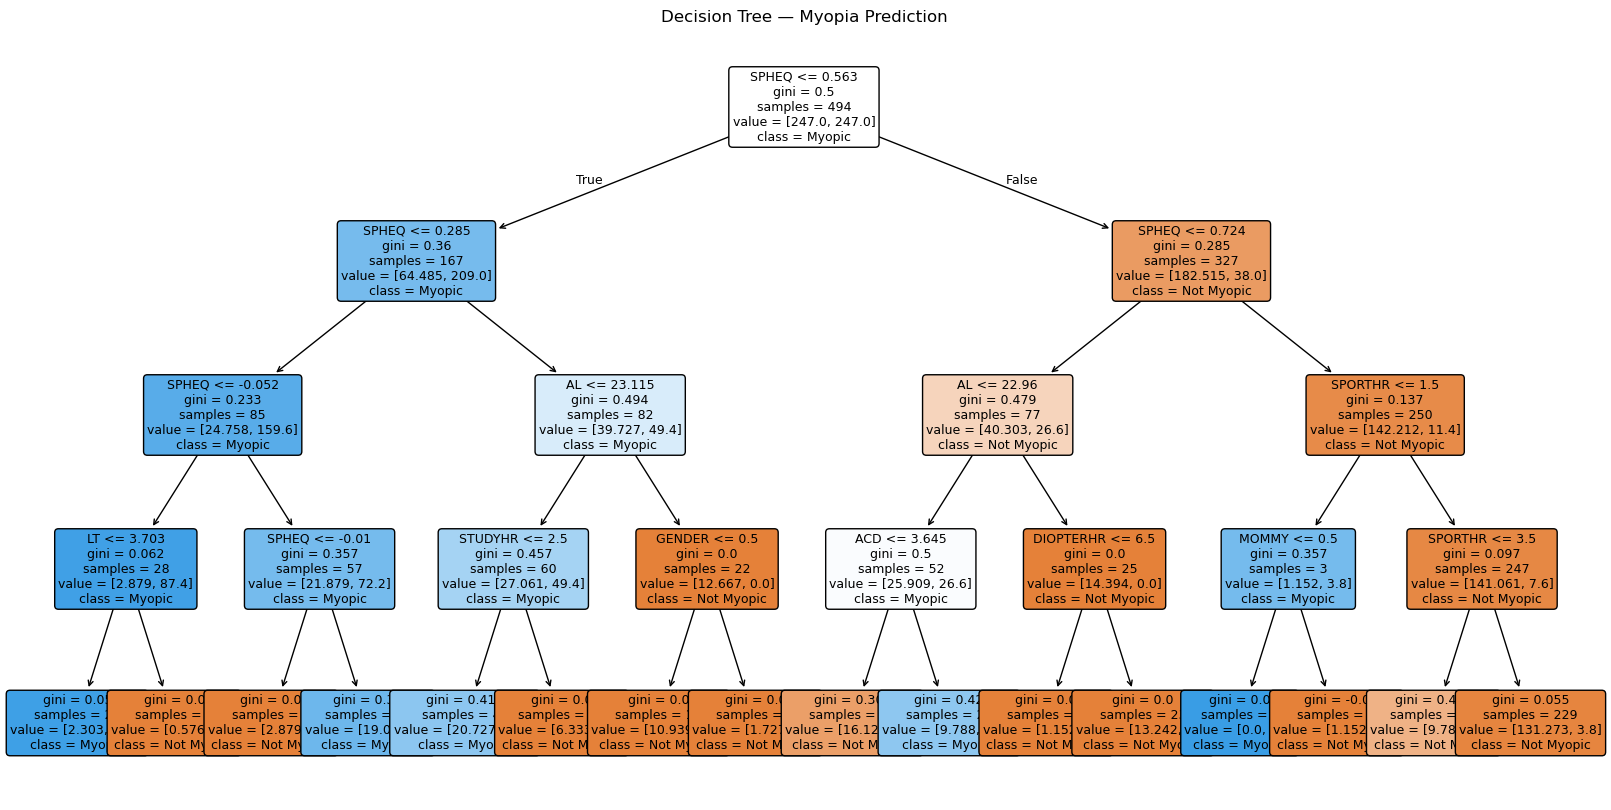

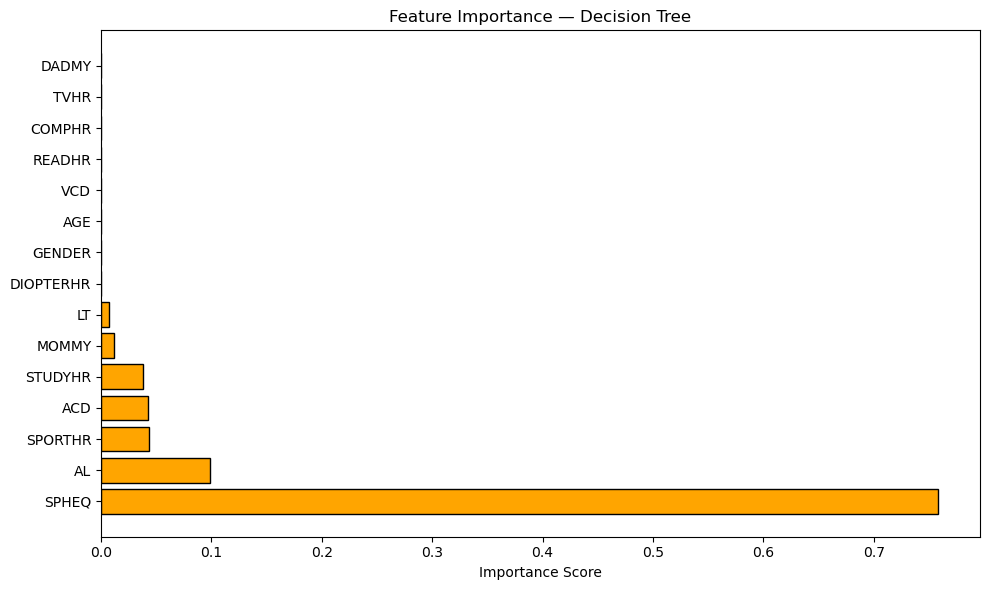


FEATURE IMPORTANCE:
      Feature    Importance
2       SPHEQ  7.583577e-01
3          AL  9.879160e-02
7     SPORTHR  4.304910e-02
4         ACD  4.254325e-02
10    STUDYHR  3.829994e-02
13      MOMMY  1.174226e-02
5          LT  7.216162e-03
12  DIOPTERHR  5.096097e-16
1      GENDER  4.297709e-16
0         AGE  0.000000e+00
6         VCD  0.000000e+00
8      READHR  0.000000e+00
9      COMPHR  0.000000e+00
11       TVHR  0.000000e+00
14      DADMY  0.000000e+00

Results saved:
{'Model': 'Decision Tree', 'Accuracy': 0.7903, 'ROC_AUC': 0.706}


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, roc_auc_score,
                             roc_curve)

# Load clean data
df = pd.read_csv("../data/myopia_model_ready.csv")

# Define features and target
X = df.drop('MYOPIC', axis=1)
y = df['MYOPIC']

# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

print("DATASET:")
print(f"Training set: {X_train.shape[0]} patients")
print(f"Testing set:  {X_test.shape[0]} patients")
print(f"Myopic in training: {y_train.sum()}")
print(f"Myopic in testing:  {y_test.sum()}")

# Train Decision Tree
model = DecisionTreeClassifier(
    max_depth=4,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)
print("\nDecision Tree trained successfully!")

# ============================================
# MAKE PREDICTIONS
# ============================================
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

# ============================================
# EVALUATION METRICS
# ============================================
print("DECISION TREE RESULTS:")
print("=" * 45)
print(f"Accuracy:  {accuracy_score(y_test, y_pred):.4f}")
print(f"ROC AUC:   {roc_auc_score(y_test, y_prob):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred,
      target_names=['Not Myopic', 'Myopic']))

# ============================================
# CONFUSION MATRIX
# ============================================
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Myopic', 'Myopic'],
            yticklabels=['Not Myopic', 'Myopic'])
plt.title("Confusion Matrix — Decision Tree")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.show()

# ============================================
# ROC CURVE
# ============================================
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, color='orange',
         linewidth=2,
         label=f'ROC Curve (AUC = {auc:.4f})')
plt.plot([0, 1], [0, 1], color='red',
         linestyle='--', label='Random Classifier')
plt.title("ROC Curve — Decision Tree")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()

# ============================================
# VISUALIZE THE TREE
# ============================================
plt.figure(figsize=(20, 10))
plot_tree(model,
          feature_names=X.columns,
          class_names=['Not Myopic', 'Myopic'],
          filled=True,
          rounded=True,
          fontsize=9)
plt.title("Decision Tree — Myopia Prediction")
plt.show()

# ============================================
# FEATURE IMPORTANCE
# ============================================
importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(importance_df['Feature'],
         importance_df['Importance'],
         color='orange', edgecolor='black')
plt.title("Feature Importance — Decision Tree")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

print("\nFEATURE IMPORTANCE:")
print(importance_df)

# Save results
dt_results = {
    'Model': 'Decision Tree',
    'Accuracy': round(accuracy_score(y_test, y_pred), 4),
    'ROC_AUC': round(roc_auc_score(y_test, y_prob), 4)
}
print("\nResults saved:")
print(dt_results)